My research questions are: 
1. Where has the most light pollution according to `LimitingMag` readings?
2. How similar is a `LimitingMag` reading vs. a reading from an SQM (`SQMReading`)?
3. How much does cloud cover impact light pollution measurements from `LimitingMag`?

The dataset I'll be using is the "Globe at Night" year dataset; specifically the 2025 dataset. Which can be found [here](https://globeatnight.org/documents/1190/GaN2025.csv).

In [1]:
import pandas as pd
import altair as alt

globe_at_night = pd.read_csv("GaN2025.csv")
globe_at_night

,ID,ObsType,Latitude,Longitude,Elevation(m),LocalDate,LocalTime,UTDate,UTTime,LimitingMag,SQMReading,SQMSerial,CloudCover,Constellation,SkyComment,LocationComment,Country
0,351408,GAN,34.959208,-116.419389,788.28,2025-11-16,23:05,2025-11-17,07:05,5,19.93,NaN,clear,Perseus,NaN,"Mojave Trails National Monument, rural",United States - California
1,351407,GAN,34.785190,-114.906398,593.78,2025-11-16,21:43,2025-11-17,05:43,4,18.93,NaN,clear,Perseus,NaN,"Rural, Mojave Trails National Monument",United States - California
2,351406,GAN,34.556519,-114.642965,524.65,2025-11-16,20:20,2025-11-17,04:20,6,20.97,NaN,1/4 of sky,Perseus,NaN,Mojave Trails National Monument. Side of a hig...,United States - California
3,351405,GAN,34.103405,-115.162542,379.68,2025-11-16,21:15,2025-11-17,05:15,6,21.10,NaN,clear,Perseus,NaN,Mojave Trails National Monument; rural,United States - California
4,351312,GAN,40.748569,-80.028031,344.48,2025-10-25,20:56,2025-10-26,00:56,0,NaN,NaN,over 1/2 of sky,Pegasus,Lots of clouds cant see stars,NaN,United States - Pennsylvania
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13397,327633,GAN,33.681894,-112.391906,397.82,2024-12-31,20:46,2025-01-01,03:46,3,NaN,NaN,1/2 of sky,Orion,NaN,Suburban,United States - Arizona
13398,327632,GAN,37.628745,-106.673847,2557.25,2024-12-31,20:35,2025-01-01,03:35,6,21.20,NaN,clear,Pegasus,NaN,NaN,United States - Colorado
13399,327631,GAN,-33.503395,-70.525980,850.40,2024-12-31,21:56,2025-01-01,00:56,4,NaN,NaN,clear,Orion,"Clear, no haze, no humidity","Outer Urban neighbourhood, low density one-sto...",Chile
13400,327625,GAN,45.095803,14.114476,208.37,2025-01-01,01:36,2025-01-01,00:36,0,NaN,NaN,clear,Pegasus,NaN,NaN,United States - Alabama


#### Variables For Research Method 1:
- Location
    - `Latitude`
    - `Longitude`
    - `Country`
- Light Readings
    - `LimitingMag`

#### Variables For Research Method 2:
- The Two Light Readings:
    - `LimitingMag`
    - `SQMReading`
    - Note:
        - Blank values and extra values, specifically for `SQMReading`, will need to be removed.
        - SQM availability is not random: it is much more common among high-LimitingMag observations (!!! I need a source for this info !!!).
- Related Variables That Could Influence The Readings:
    - `CloudCover`
    - `Constellation`
### Variables For Research Method 3:
- The Actual Cloud Cover Measurement
    - `CloudCover`
- Light Readings
    - `LimitingMag`
- Note:
    - Other variables need to be controlled for to truly determine the impact of cloud cover. To do this I will take the location, time and date, and constellation into account (maybe also seeing whether elevation influences it).
- Control Variables
    - `Latitude`
    - `Longitude`
    - `LocalDate` and `LocalTime`
    - `Constellation`
    - `Elevation(m)`

In [2]:
# grabs the desired columns
desired_columns = [
    "ID",
    "LimitingMag",
    "SQMReading",
    "CloudCover",
    "Latitude",
    "Longitude",
    "Country",
    "Elevation(m)",
    "LocalDate",
    "LocalTime",
    #"UTDate",
    #"UTTime",
    "Constellation",
]

gan_desired = globe_at_night[desired_columns].copy()

##### First, I want to look into the variables in the data a little bit

In [3]:
gan_desired.shape
gan_desired.info()

<class 'pandas.DataFrame'>
RangeIndex: 13402 entries, 0 to 13401
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             13402 non-null  int64  
 1   LimitingMag    13402 non-null  int64  
 2   SQMReading     2992 non-null   float64
 3   CloudCover     13402 non-null  str    
 4   Latitude       13402 non-null  float64
 5   Longitude      13402 non-null  float64
 6   Country        13402 non-null  str    
 7   Elevation(m)   13402 non-null  float64
 8   LocalDate      13402 non-null  str    
 9   LocalTime      13402 non-null  str    
 10  Constellation  13402 non-null  str    
dtypes: float64(4), int64(2), str(5)
memory usage: 1.1 MB


In [4]:
gan_desired.sample(10, random_state=69)

,ID,LimitingMag,SQMReading,CloudCover,Latitude,Longitude,Country,Elevation(m),LocalDate,LocalTime,Constellation
4170,337543,1,NaN,1/2 of sky,-6.914048,107.597005,Indonesia,712.47,2025-09-21,22:22,Grus
7766,333598,4,NaN,clear,38.930430,-76.509214,United States - Maryland,8.89,2025-04-27,21:31,Leo
5458,335980,6,20.70,clear,40.035607,-82.197614,United States - Ohio,297.22,2025-07-22,22:41,Hercules
1889,340044,6,20.58,clear,29.872047,-98.631313,United States - Texas,393.60,2025-11-12,00:10,Perseus
158,341998,0,NaN,clear,0.000000,0.000000,United States - Michigan,0.00,2025-12-16,13:59,Perseus
938,341017,2,NaN,1/4 of sky,17.997635,-66.103817,Puerto Rico,78.38,2025-12-10,20:37,Perseus
8838,332525,3,NaN,clear,40.645612,-3.337003,Spain,721.96,2025-03-25,21:53,Leo
1064,340890,0,NaN,clear,0.000000,0.000000,United States - Alabama,0.00,2025-12-03,23:12,Perseus
7000,334364,0,NaN,1/2 of sky,38.909178,-77.162735,United States - Virginia,123.66,2025-05-06,22:31,Leo
6518,334913,3,17.00,clear,-34.903663,-56.175643,Uruguay,43.31,2025-05-29,20:19,Crux


From this, I can see that some of the `Latitude` and `Longitude` values aren't even filled in. In the case above, it was for `ID:340890` and the other was for `ID:341998` for both of those the reading for `LimitingMag` was also at `0.0`. So maybe I could just remove any entries where the `Latitude` and `Longitude` are `0.0`.

I had also seen this from opening the dataset for a second, but it looks like readings from the SQM are often not available. Though, I believe that more often the `LimitingMag` is available based on what I'm seeing.

With the `Country` data, it looks like the United States is categorized based on state, but keeps the state value in the column. Maybe I could split those, but because other countries don't do it, I may just extract the state after anaylsis if the value was from the United States.

In [5]:
gan_desired[
    [
        "Latitude",
        "Longitude",
        "Elevation(m)",
        "LimitingMag",
        "SQMReading",
    ]
].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

,Latitude,Longitude,Elevation(m),LimitingMag,SQMReading
count,13402.000000,13402.000000,13402.000000,13402.000000,2.992000e+03
mean,26.433893,-49.324199,311.194431,2.404343,3.342246e+86
std,22.641433,68.377548,564.738605,1.975219,1.828181e+88
min,-89.999959,-160.483957,-9198.540000,0.000000,2.000000e-02
1%,-34.907735,-122.578344,0.000000,0.000000,1.000000e+00
5%,-30.608982,-119.819483,0.000000,0.000000,2.000000e+00
25%,17.985100,-92.618376,38.440000,1.000000,1.661000e+01
50%,35.120115,-76.886810,173.060000,2.000000,1.888000e+01
75%,40.474383,0.000000,354.340000,4.000000,2.066000e+01
95%,47.498442,107.629472,1454.430000,6.000000,2.153890e+01


From looking at the data, I want to:
1. Split the states from the United States to get more specific locations in the U.S.
2. Remove the false readings that have `Latitude = 0.0` and `Longitude = 0.0` values.

In [6]:
# splits instances like 
# "United States - Missouri"
# by the " - "
country_vals = gan_desired['Country'].str.split(
    " - ",
    n=1,
    expand=True,
)

# removes the old values in the 'Country' column
gan_desired = gan_desired.drop(columns='Country')

# saves the split values into their
# own separate columns
gan_desired['Country'] = country_vals[0]
gan_desired['State'] = country_vals[1]

gan_desired

,ID,LimitingMag,SQMReading,CloudCover,Latitude,Longitude,Elevation(m),LocalDate,LocalTime,Constellation,Country,State
0,351408,5,19.93,clear,34.959208,-116.419389,788.28,2025-11-16,23:05,Perseus,United States,California
1,351407,4,18.93,clear,34.785190,-114.906398,593.78,2025-11-16,21:43,Perseus,United States,California
2,351406,6,20.97,1/4 of sky,34.556519,-114.642965,524.65,2025-11-16,20:20,Perseus,United States,California
3,351405,6,21.10,clear,34.103405,-115.162542,379.68,2025-11-16,21:15,Perseus,United States,California
4,351312,0,NaN,over 1/2 of sky,40.748569,-80.028031,344.48,2025-10-25,20:56,Pegasus,United States,Pennsylvania
...,...,...,...,...,...,...,...,...,...,...,...,...
13397,327633,3,NaN,1/2 of sky,33.681894,-112.391906,397.82,2024-12-31,20:46,Orion,United States,Arizona
13398,327632,6,21.20,clear,37.628745,-106.673847,2557.25,2024-12-31,20:35,Pegasus,United States,Colorado
13399,327631,4,NaN,clear,-33.503395,-70.525980,850.40,2024-12-31,21:56,Orion,Chile,NaN
13400,327625,0,NaN,clear,45.095803,14.114476,208.37,2025-01-01,01:36,Pegasus,United States,Alabama


In [7]:
gan_desired = gan_desired[~(
    (gan_desired['Latitude'] == 0.0) & (gan_desired['Longitude'] == 0.0)
    | gan_desired['Latitude'].isna()
    | gan_desired['Longitude'].isna()
    )].reset_index(drop=True)

((gan_desired['Latitude'] == 0) & (gan_desired['Longitude'] == 0)).sum()
gan_desired.sample(10, random_state=69)

,ID,LimitingMag,SQMReading,CloudCover,Latitude,Longitude,Elevation(m),LocalDate,LocalTime,Constellation,Country,State
11962,328506,3,NaN,clear,50.857686,2.871238,19.38,2025-01-27,11:30,Orion,Belgium,NaN
8749,332026,1,NaN,over 1/2 of sky,45.101312,14.105216,221.28,2025-03-27,20:44,Orion,Croatia,NaN
2298,339374,2,NaN,clear,34.379761,-84.942169,213.12,2025-10-23,22:32,Pegasus,United States,Georgia
2333,339339,1,NaN,over 1/2 of sky,-34.482046,-55.635480,81.20,2025-10-23,19:49,Grus,Uruguay,NaN
328,341585,2,NaN,1/2 of sky,18.004103,-65.875255,10.59,2025-12-18,20:23,Perseus,Puerto Rico,NaN
1615,340205,4,18.19,1/2 of sky,18.000104,-66.618459,9.04,2025-11-16,22:09,Perseus,Puerto Rico,NaN
7139,333753,0,3.00,clear,40.951518,-76.883215,161.91,2025-04-08,21:30,Leo,United States,Pennsylvania
564,341340,1,NaN,1/2 of sky,17.985160,-66.051260,32.45,2025-12-14,20:17,Perseus,Puerto Rico,NaN
3661,337753,2,NaN,1/2 of sky,-34.492978,-55.568587,40.58,2025-09-22,22:30,Grus,Uruguay,NaN
12433,327956,3,NaN,clear,48.259124,14.204556,293.49,2025-01-10,22:29,Orion,Austria,NaN


##### Now all of the invalid location reading are removed!

Next, I want to set up a few dataframes for the research questions

#### 1. Where has the most light pollution according to `LimitingMag` readings?
I am looking for:
- Location
    - `Latitude`
    - `Longitude`
    - `Country`
    - `State`
- Light Readings
    - `LimitingMag`

In [8]:
q_1_columns = [
    "ID",
    "Latitude",
    "Longitude",
    "Country",
    "State",
    "LimitingMag"
]

most_light_pollution_data = gan_desired[q_1_columns].copy()
most_light_pollution_data

,ID,Latitude,Longitude,Country,State,LimitingMag
0,351408,34.959208,-116.419389,United States,California,5
1,351407,34.785190,-114.906398,United States,California,4
2,351406,34.556519,-114.642965,United States,California,6
3,351405,34.103405,-115.162542,United States,California,6
4,351312,40.748569,-80.028031,United States,Pennsylvania,0
...,...,...,...,...,...,...
12519,327633,33.681894,-112.391906,United States,Arizona,3
12520,327632,37.628745,-106.673847,United States,Colorado,6
12521,327631,-33.503395,-70.525980,Chile,NaN,4
12522,327625,45.095803,14.114476,United States,Alabama,0


2. How similar is a `LimitingMag` reading vs. a reading from an SQM (`SQMReading`)?
- The Two Light Readings:
    - `LimitingMag`
    - `SQMReading`
    - Note:
        - Blank values and extra values, specifically for `SQMReading`, will need to be removed.
        - SQM availability is not random: it is much more common among high-LimitingMag observations (!!! I need a source for this info !!!).
- Related Variables That Could Influence The Readings:
    - `CloudCover`
    - `Constellation`

In [ ]:
q_2_columns = [
    "ID",
    "LimitingMag",
    "SQMReading",
    "CloudCover",
    "Constellation",
]

# selects for the desired columns related to the questions
# removes rows that don't have SQMReading values
limitingMag_SQMReading_data = gan_desired[q_2_columns].dropna(subset=["SQMReading"]).reset_index(drop=True)
limitingMag_SQMReading_data

,ID,LimitingMag,SQMReading,CloudCover,Constellation
0,351408,5,19.93,clear,Perseus
1,351407,4,18.93,clear,Perseus
2,351406,6,20.97,1/4 of sky,Perseus
3,351405,6,21.10,clear,Perseus
4,351286,6,21.64,clear,Perseus
...,...,...,...,...,...
2865,327650,5,20.35,clear,Pegasus
2866,327649,6,20.74,clear,Orion
2867,327648,6,20.60,clear,Pegasus
2868,327647,5,20.27,clear,Orion


3. How much does cloud cover impact light pollution measurements from `LimitingMag`?
- The Actual Cloud Cover Measurement
    - `CloudCover`
- Light Readings
    - `LimitingMag`
- Note:
    - Other variables need to be controlled for to truly determine the impact of cloud cover. To do this I will take the location, time and date, and constellation into account (maybe also seeing whether elevation influences it).
- Control Variables
    - `Latitude`
    - `Longitude`
    - `LocalDate` and `LocalTime`
    - `Constellation`
    - `Elevation(m)`

In [10]:
q_3_columns = [
    "ID",
    "LimitingMag",
    "CloudCover",
    "Latitude",
    "Longitude",
    "Elevation(m)",
    "LocalDate",
    "LocalTime",
    "Constellation",
]

cloud_cover_data = gan_desired[q_3_columns].copy()
cloud_cover_data

,ID,LimitingMag,CloudCover,Latitude,Longitude,Elevation(m),LocalDate,LocalTime,Constellation
0,351408,5,clear,34.959208,-116.419389,788.28,2025-11-16,23:05,Perseus
1,351407,4,clear,34.785190,-114.906398,593.78,2025-11-16,21:43,Perseus
2,351406,6,1/4 of sky,34.556519,-114.642965,524.65,2025-11-16,20:20,Perseus
3,351405,6,clear,34.103405,-115.162542,379.68,2025-11-16,21:15,Perseus
4,351312,0,over 1/2 of sky,40.748569,-80.028031,344.48,2025-10-25,20:56,Pegasus
...,...,...,...,...,...,...,...,...,...
12519,327633,3,1/2 of sky,33.681894,-112.391906,397.82,2024-12-31,20:46,Orion
12520,327632,6,clear,37.628745,-106.673847,2557.25,2024-12-31,20:35,Pegasus
12521,327631,4,clear,-33.503395,-70.525980,850.40,2024-12-31,21:56,Orion
12522,327625,0,clear,45.095803,14.114476,208.37,2025-01-01,01:36,Pegasus


Now I have a dataframe with the pertinent variables for each research question.
1. `most_light_pollution_data`
2. `limitingMag_SQMReading_data`
3. `cloud_cover_data`

Now I can answer the questions with the data.

3. How much does cloud cover impact light pollution measurements from `LimitingMag`?

1. Where has the most light pollution according to `LimitingMag` readings?

Available columns:
`ID	Latitude	Longitude	Country	State	LimitingMag`

Because each location has multiple `LimitingMag` values from multiple different dates, I think I would take an average of `LimitingMag` values and then plot `LimitingMag` across one dimension and then label Countries (and States if in the U.S.) on that line.

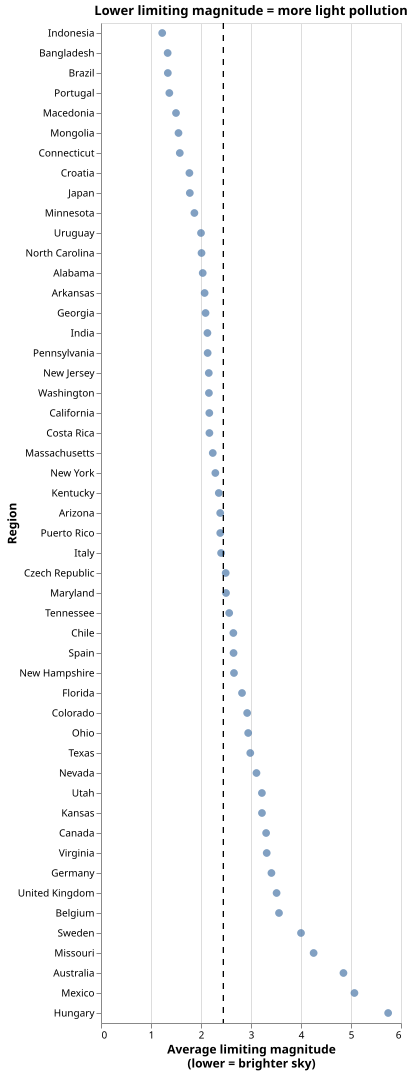

In [ ]:
# I guess that I could remove the ID because it's really
# the location that is important. Not the individual IDs.
average_by_limitingMag = most_light_pollution_data.groupby(["ID", "Country", "State", "Latitude", "Longitude"], as_index=False)["LimitingMag"].mean()

# groups readings with the same country and state
# Then gets the mean LimitingMag value
# And also grabs how many Readings There were
# that went into that mean
average_by_region = (
    most_light_pollution_data
    .groupby(["Country", "State"], dropna=False, as_index=False)
    .agg(LimitingMag=("LimitingMag", "mean"), ReadingsQuantity=("ID", "size"))
)

# Uses the State name for any U.S. observations
# otherwise puts the name of the country is the State
# is not available.
average_by_region["Region"] = average_by_region["State"].fillna(average_by_region["Country"])

reliable_regions = average_by_region[average_by_region["ReadingsQuantity"] >= 30]

# allows the plot to be output to an SVG image
alt.renderers.enable("svg")

# puts together a plot of light pollution
# relative to which country/state is observed
light_pollution_graph = alt.Chart(reliable_regions, title="Lower limiting magnitude = more light pollution").mark_circle(size=60).encode(
    x=alt.X("LimitingMag").title(["Average limiting magnitude", "(lower = brighter sky)"]),
    y=alt.Y("Region:N").sort("x").title("Region"),
)

# prints an average line for all mean values on the graph
mean_line = alt.Chart(reliable_regions).mark_rule(strokeDash=[6]).encode(
    x=alt.datum(most_light_pollution_data["LimitingMag"].mean())
)

# this puts the mean line over the graph
# and also sets the font size for the axis
# titles
(light_pollution_graph + mean_line).configure_axis(titleFontSize=12)

2. How similar is a `LimitingMag` reading vs. a reading from an SQM (`SQMReading`)?

Available variables:
- "ID",
- "LimitingMag",
- "SQMReading",
- "CloudCover",
- "Constellation",

Apparently astronomers already have a conversion between LimitingMag reading and SQMReadings called Crumey's / Unihedron's approximation. So I will use that to convert the SQM readings to comparable values.

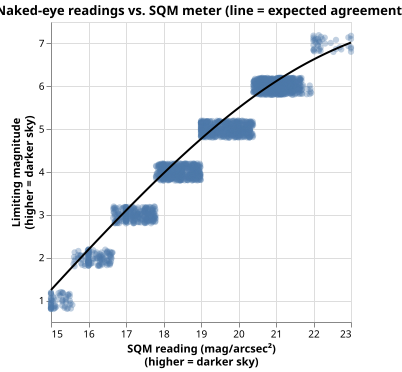

In [21]:
import numpy as np

pairs = limitingMag_SQMReading_data[
    (limitingMag_SQMReading_data["LimitingMag"] > 0)
    & limitingMag_SQMReading_data["SQMReading"].between(15, 23)
].copy()

# expected LimitingMag for a given SQM reading
def lm_from_sqm(sqm):
    return 7.93 - 5 * np.log10(10 ** (4.316 - sqm / 5) + 1)

curve = pd.DataFrame({"SQMReading": np.linspace(15, 23, 200)})
curve["LimitingMag"] = lm_from_sqm(curve["SQMReading"])

points = alt.Chart(pairs).transform_calculate(
    # spreads the whole-number readings out so they don't stack
    LM_jitter="datum.LimitingMag + (random() - 0.5) * 0.4"
).mark_circle(size=40, opacity=0.35).encode(
    x=alt.X("SQMReading:Q").scale(domain=[15, 23]).title(["SQM reading (mag/arcsec²)", "(higher = darker sky)"]),
    y=alt.Y("LM_jitter:Q").scale(domain=[0.5, 7.5]).title(["Limiting magnitude", "(higher = darker sky)"]),
    tooltip=["LimitingMag", "SQMReading", "CloudCover"],
)

expected = alt.Chart(curve).mark_line(color="black", strokeWidth=2).encode(
    x="SQMReading:Q",
    y="LimitingMag:Q",
)

sqm_vs_lm_graph = (points + expected).properties(
    title="Naked-eye readings vs. SQM meter (line = expected agreement)"
)
sqm_vs_lm_graph


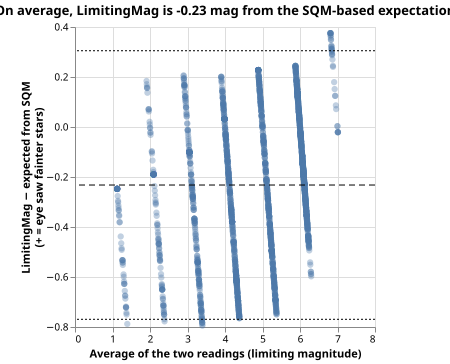

In [22]:
pairs["LM_from_SQM"] = lm_from_sqm(pairs["SQMReading"])
pairs["diff"] = pairs["LimitingMag"] - pairs["LM_from_SQM"]
pairs["avg"] = (pairs["LimitingMag"] + pairs["LM_from_SQM"]) / 2

bias = pairs["diff"].mean()
sd = pairs["diff"].std()
lines = pd.DataFrame({
    "value": [bias, bias - 1.96 * sd, bias + 1.96 * sd],
    "label": ["Mean difference", "Lower 95% limit", "Upper 95% limit"],
})

diff_points = alt.Chart(pairs).mark_circle(size=40, opacity=0.35).encode(
    x=alt.X("avg:Q").title("Average of the two readings (limiting magnitude)"),
    y=alt.Y("diff:Q").title(["LimitingMag − expected from SQM", "(+ = eye saw fainter stars)"]),
    tooltip=["LimitingMag", "SQMReading", alt.Tooltip("diff:Q", format=".2f")],
)

rules = alt.Chart(lines).mark_rule(color="black").encode(
    y="value:Q",
    strokeDash=alt.condition(
        alt.datum.label == "Mean difference", alt.value([6, 4]), alt.value([2, 2])
    ),
    tooltip=["label", alt.Tooltip("value:Q", format=".2f")],
)

bland_altman_graph = (diff_points + rules).properties(
    title=f"On average, LimitingMag is {bias:+.2f} mag from the SQM-based expectation"
)
bland_altman_graph


These two graphs are kind of hard to interpret.